In [10]:
import json
import os


path = "../../output/protenn2/v5/"
with open(os.path.join(path, "metrics_test.json")) as f:
    metrics_final = json.load(f)
metrics_final

{'raw_C': {'accuracy': {'mean': 0.7405355301156626,
   'ci_lower': 0.7275101748438831,
   'ci_upper': 0.7535130083025426,
   'alpha': 0.05},
  'f1_score': {'mean': 0.744339495822709,
   'ci_lower': 0.7316071547178614,
   'ci_upper': 0.7573192919824875,
   'alpha': 0.05},
  'jaccard_score': {'mean': 0.6421667700133491,
   'ci_lower': 0.6233962666428363,
   'ci_upper': 0.6601067050887938,
   'alpha': 0.05},
  'recall_score': {'mean': 0.7426245972005572,
   'ci_lower': 0.7261152452099787,
   'ci_upper': 0.7588202688122467,
   'alpha': 0.05},
  'precision_score': {'mean': 0.8257673874612286,
   'ci_lower': 0.810777303724634,
   'ci_upper': 0.8406897899388556,
   'alpha': 0.05},
  'segment_overlap_score': {'mean': 0.5356392953107524,
   'ci_lower': 0.5136016168117169,
   'ci_upper': 0.55665021316302,
   'alpha': 0.05}},
 'post_C': {'accuracy': {'mean': 0.6809834374427128,
   'ci_lower': 0.6640471308126129,
   'ci_upper': 0.6979512281158442,
   'alpha': 0.05},
  'f1_score': {'mean': 0.684982

In [11]:
import numpy as np
data = metrics_final
model_keys = ['raw', 'post', 'two_tier', 'baseline']
groups = ['C', 'A', 'T', 'H']
metrics = ['accuracy', 'f1_score', 'jaccard_score', 'recall_score', 'precision_score', 'segment_overlap_score']

# Initialize containers
results = {
    metric: {
        'mean': {model: [] for model in model_keys},
        'ci_lower': {model: [] for model in model_keys},
        'ci_upper': {model: [] for model in model_keys}
    } for metric in metrics
}

# Extract and round values
for metric in metrics:
    for model in model_keys:
        for group in groups:
            key = f"{model}_{group}"
            values = data.get(key, {}).get(metric, {})
            ci_lower = values.get('ci_lower', 0.0)
            ci_upper = values.get('ci_upper', 0.0)
            results[metric]['mean'][model].append(round(float(np.mean([ci_lower, ci_upper])), 2))
            results[metric]['ci_lower'][model].append(round(ci_lower, 2))
            results[metric]['ci_upper'][model].append(round(ci_upper, 2))

# Print results
for metric in metrics:
    print(f"\n{metric.upper()}")
    for stat in ['mean', 'ci_lower', 'ci_upper']:
        for model in model_keys:
            print(f"{model}_{metric}_{stat} = {results[metric][stat][model]}")
        print()



ACCURACY
raw_accuracy_mean = [0.74, 0.71, 0.7, 0.69]
post_accuracy_mean = [0.68, 0.67, 0.67, 0.66]
two_tier_accuracy_mean = [0.7, 0.64, 0.62, 0.61]
baseline_accuracy_mean = [0.33, 0.33, 0.33, 0.33]

raw_accuracy_ci_lower = [0.73, 0.7, 0.69, 0.67]
post_accuracy_ci_lower = [0.66, 0.66, 0.65, 0.65]
two_tier_accuracy_ci_lower = [0.68, 0.62, 0.6, 0.58]
baseline_accuracy_ci_lower = [0.31, 0.31, 0.31, 0.31]

raw_accuracy_ci_upper = [0.75, 0.73, 0.71, 0.7]
post_accuracy_ci_upper = [0.7, 0.69, 0.69, 0.68]
two_tier_accuracy_ci_upper = [0.72, 0.67, 0.65, 0.63]
baseline_accuracy_ci_upper = [0.35, 0.35, 0.35, 0.35]


F1_SCORE
raw_f1_score_mean = [0.74, 0.72, 0.69, 0.67]
post_f1_score_mean = [0.68, 0.67, 0.64, 0.62]
two_tier_f1_score_mean = [0.68, 0.63, 0.61, 0.6]
baseline_f1_score_mean = [0.17, 0.17, 0.17, 0.17]

raw_f1_score_ci_lower = [0.73, 0.7, 0.68, 0.66]
post_f1_score_ci_lower = [0.67, 0.66, 0.63, 0.6]
two_tier_f1_score_ci_lower = [0.65, 0.61, 0.59, 0.57]
baseline_f1_score_ci_lower = [0.15, 

accuracy


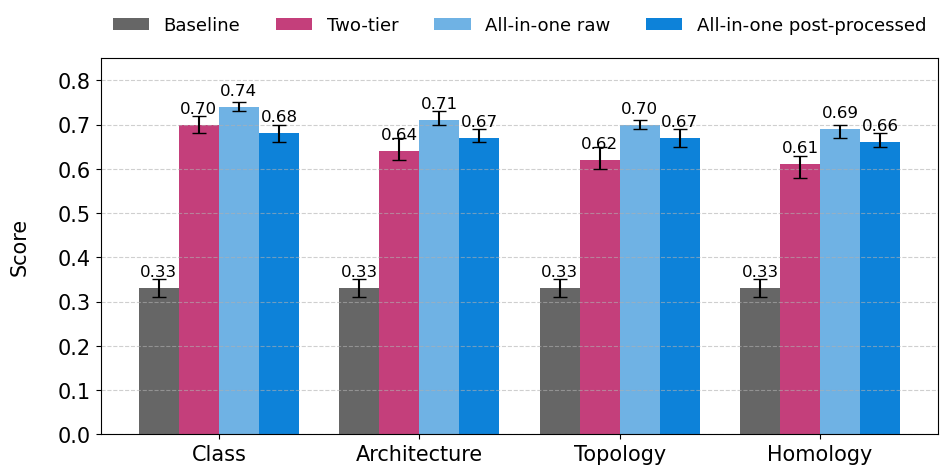

f1_score


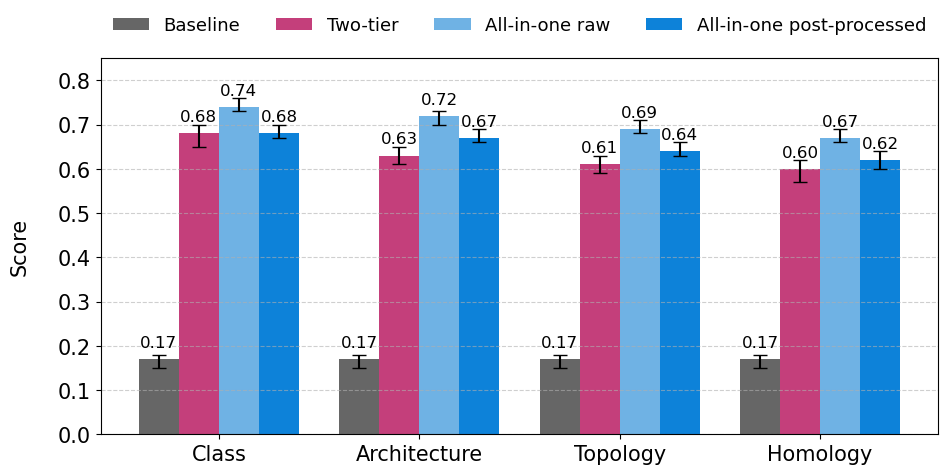

segment_overlap_score


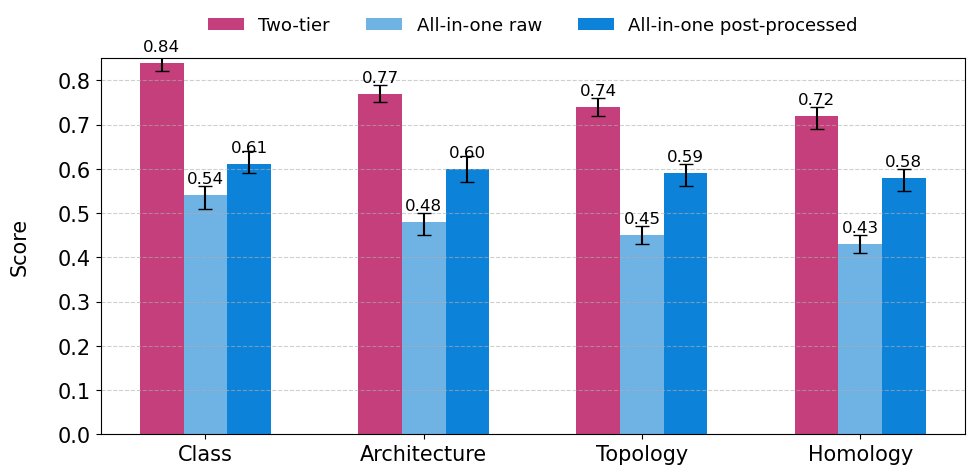

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data
levels = ["Class", "Architecture", "Topology", "Homology"]
x = np.arange(len(levels))
bar_width = 0.2

for metric in ['accuracy', 'f1_score', 'segment_overlap_score']:
    baseline_mean = results[metric]["mean"]["baseline"]
    baseline_ci_lower = results[metric]["ci_lower"]["baseline"]
    baseline_ci_upper = results[metric]["ci_upper"]["baseline"]

    raw_mean = results[metric]["mean"]["raw"]
    raw_ci_lower = results[metric]["ci_lower"]["raw"]
    raw_ci_upper = results[metric]["ci_upper"]["raw"]

    post_mean = results[metric]["mean"]["post"]
    post_ci_lower = results[metric]["ci_lower"]["post"]
    post_ci_upper = results[metric]["ci_upper"]["post"]

    two_tier_mean = results[metric]["mean"]["two_tier"]
    two_tier_ci_lower = results[metric]["ci_lower"]["two_tier"]
    two_tier_ci_upper = results[metric]["ci_upper"]["two_tier"]

    baseline_error = [np.array(baseline_mean) - np.array(baseline_ci_lower),
                  np.array(baseline_ci_upper) - np.array(baseline_mean)]
    raw_error = [np.array(raw_mean) - np.array(raw_ci_lower),
                 np.array(raw_ci_upper) - np.array(raw_mean)]
    post_error = [np.array(post_mean) - np.array(post_ci_lower),
                  np.array(post_ci_upper) - np.array(post_mean)]
    two_tier_error = [np.array(two_tier_mean) - np.array(two_tier_ci_lower),
                      np.array(two_tier_ci_upper) - np.array(two_tier_mean)]

    # Custom colors
    colors = ['#666666', '#6FB2E4', '#0d82d9', '#C43F7B']

    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 15})

    # Plot bars

    if metric == "segment_overlap_score":
        bars1 = None
        bars2 = plt.bar(x - bar_width, two_tier_mean, width=bar_width,
                        yerr=two_tier_error, capsize=5, label='Two-tier', color=colors[3])
        bars3 = plt.bar(x, raw_mean, width=bar_width,
                        yerr=raw_error, capsize=5, label='All-in-one raw', color=colors[1])
        bars4 = plt.bar(x + bar_width, post_mean, width=bar_width,
                        yerr=post_error, capsize=5, label='All-in-one post-processed', color=colors[2])
    else:
        bars1 = plt.bar(x - 1.5 * bar_width, baseline_mean, width=bar_width,
                        yerr=baseline_error, capsize=5, label='Baseline', color=colors[0])
        bars2 = plt.bar(x - 0.5 * bar_width, two_tier_mean, width=bar_width,
                        yerr=two_tier_error, capsize=5, label='Two-tier', color=colors[3])
        bars3 = plt.bar(x + 0.5 * bar_width, raw_mean, width=bar_width,
                        yerr=raw_error, capsize=5, label='All-in-one raw', color=colors[1])
        bars4 = plt.bar(x + 1.5 * bar_width, post_mean, width=bar_width,
                        yerr=post_error, capsize=5, label='All-in-one post-processed', color=colors[2])



    # Add text on top of bars
    def label_bars(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02,
                     f"{height:.2f}", ha='center', va='bottom', fontsize=12)


    if bars1:
        label_bars(bars1)
    label_bars(bars2)
    label_bars(bars3)
    label_bars(bars4)

    # Formatting
    plt.xticks(x, levels)
    plt.ylabel("Score", labelpad=20)
    # plt.xlabel("CATH Hierarchy Level", labelpad=20)
    # Place legend above the plot
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
               ncol=4, frameon=False, fontsize=13)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.ylim(0, 0.85)  # Adjusted for the data range
    plt.savefig(f"../../output/protenn2/v5/{metric}.png")
    print(metric)
    plt.show()